### ***Lasso Regression***

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge

In [ ]:
# Loading the dataset
df=pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
df = pd.read_csv("Life Expectancy Data.csv")
df.columns = df.columns.str.strip()

# Drop rows where the target variable 'Life expectancy' is missing
df = df.dropna(subset=['Life expectancy'])

# Fill remaining numeric missing values with the mean of their respective columns
df.fillna(df.mean(numeric_only=True), inplace=True)

df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


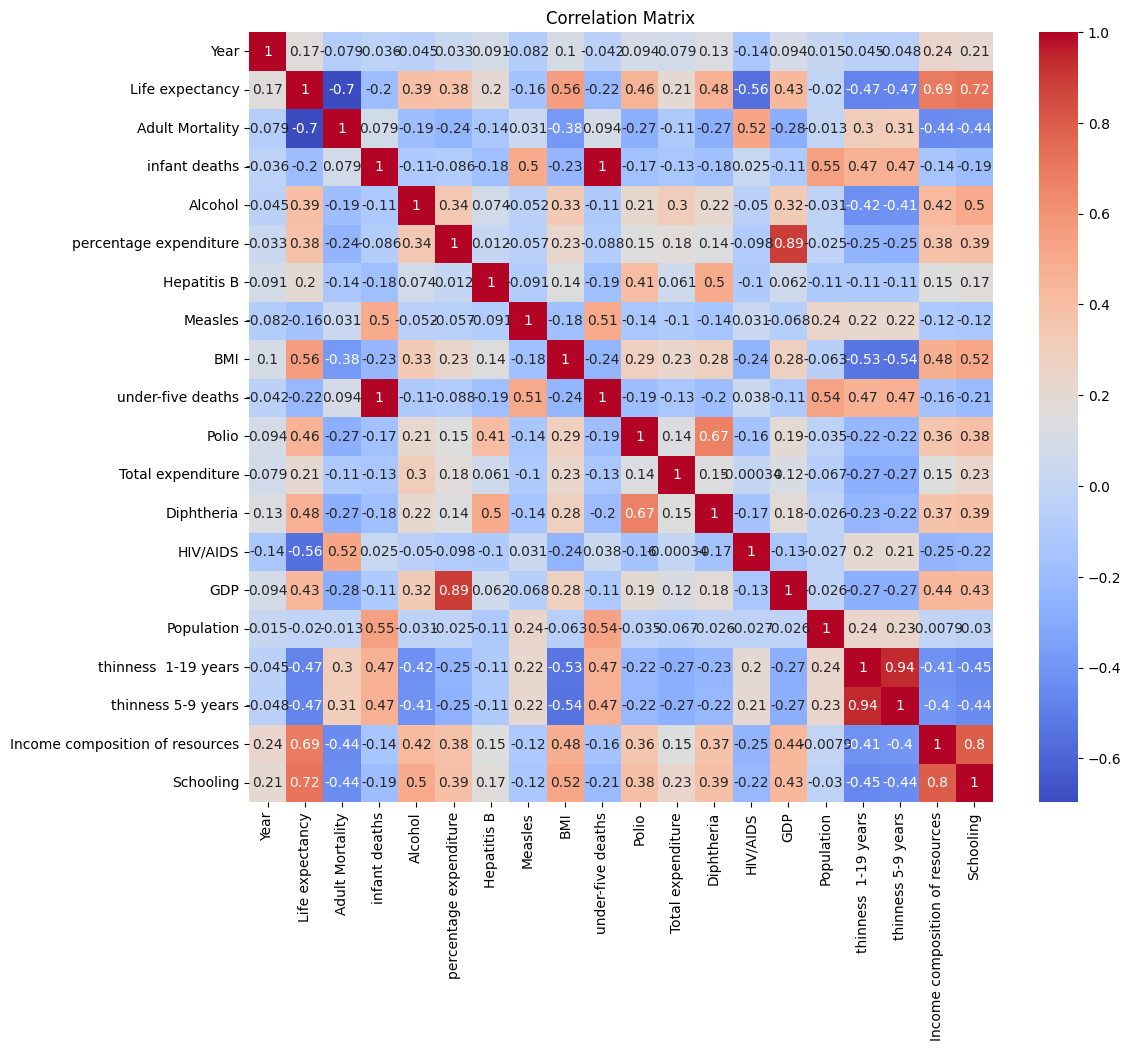

In [ ]:
# Creating a correlation matrix plot to visualize relationships between numerical features
plt.figure(figsize=(12,10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm',annot =True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Extracting and sorting correlations with 'Life expectancy'
corr_target = correlation_matrix['Life expectancy'].sort_values(ascending=False)
print(corr_target)

Life expectancy                    1.000000
Schooling                          0.718614
Income composition of resources    0.692621
BMI                                0.562453
Diphtheria                         0.476442
Polio                              0.462592
GDP                                0.430551
Alcohol                            0.392420
percentage expenditure             0.381864
Total expenditure                  0.209628
Hepatitis B                        0.204566
Year                               0.170033
Population                        -0.019629
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.467231
thinness  1-19 years              -0.472778
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64


In [ ]:
# Selecting features with an absolute correlation
selected_features = corr_target[abs(corr_target) > 0.45].index
selected_features = selected_features.drop('Life expectancy')
print("Selected Features:\n", selected_features)

Selected Features:
 Index(['Schooling', 'Income composition of resources', 'BMI', 'Diphtheria',
       'Polio', 'thinness 5-9 years', 'thinness  1-19 years', 'HIV/AIDS',
       'Adult Mortality'],
      dtype='object')


In [ ]:
#selecting target and features
X = df[selected_features]
y = df['Life expectancy']

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Initializing the StandardScaler
scaler = StandardScaler()
#fit and transform data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# calculating r2 score on alpha values
alphas = np.logspace(-4, 2, 50)
r2_scores = []
for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2_scores.append(r2_score(y_test, y_pred))

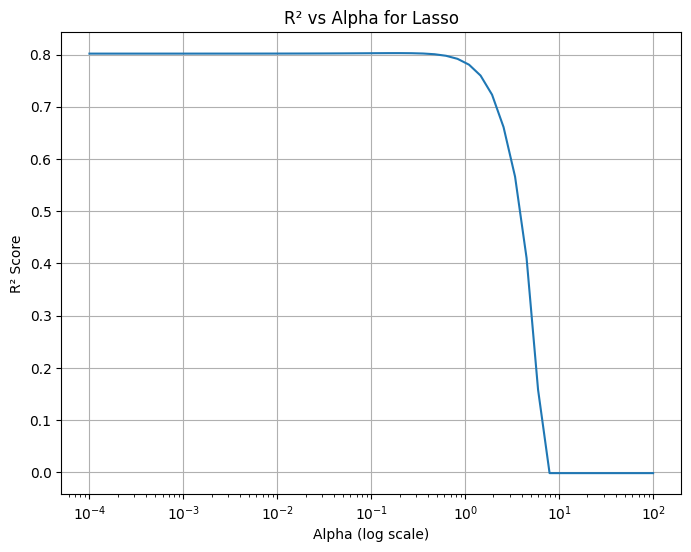

In [ ]:
# r2 score vs alpha for lasso
plt.figure(figsize=(8,6))
plt.plot(alphas, r2_scores)
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("R² Score")
plt.title("R² vs Alpha for Lasso")
plt.grid(True)
plt.show()

In [ ]:
# Using LassoCV to find the optimal alpha
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
best_alpha = lasso_cv.alpha_
print("Best Alpha selected by LassoCV:", best_alpha)

Best Alpha selected by LassoCV: 0.03727593720314938


In [ ]:
# Initializing and model fit for a Lasso model with the best alpha
lasso_model = Lasso(alpha=best_alpha)
lasso_model.fit(X_train_scaled, y_train)

y_pred = lasso_model.predict(X_test_scaled)

In [ ]:
#mse , rmse, r2 score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 4.137310291502665
R² Score: 0.8021103500308792


In [ ]:
 # Retraining the Lasso model on the training data with the last alpha value
model.fit(X_train_scaled, y_train)

Lasso(alpha=np.float64(100.0), max_iter=10000)

In [ ]:
# Making predictions on the scaled data
train_pred = lasso_model.predict(X_train_scaled)
test_pred = lasso_model.predict(X_test_scaled)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Train R²: 0.8003153016604206
Test R²: 0.8021103500308792


In [ ]:
 # Creating a DataFrame to store feature names and their corresponding Lasso coefficients
feature_coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lasso_model.coef_
})

print(feature_coefficients.sort_values(by="Coefficient", ascending=False))

                           Feature  Coefficient
0                        Schooling     2.532694
1  Income composition of resources     1.450816
3                       Diphtheria     0.961618
2                              BMI     0.896640
4                            Polio     0.762764
5               thinness 5-9 years    -0.000000
6             thinness  1-19 years    -0.621811
7                         HIV/AIDS    -2.442540
8                  Adult Mortality    -2.654672


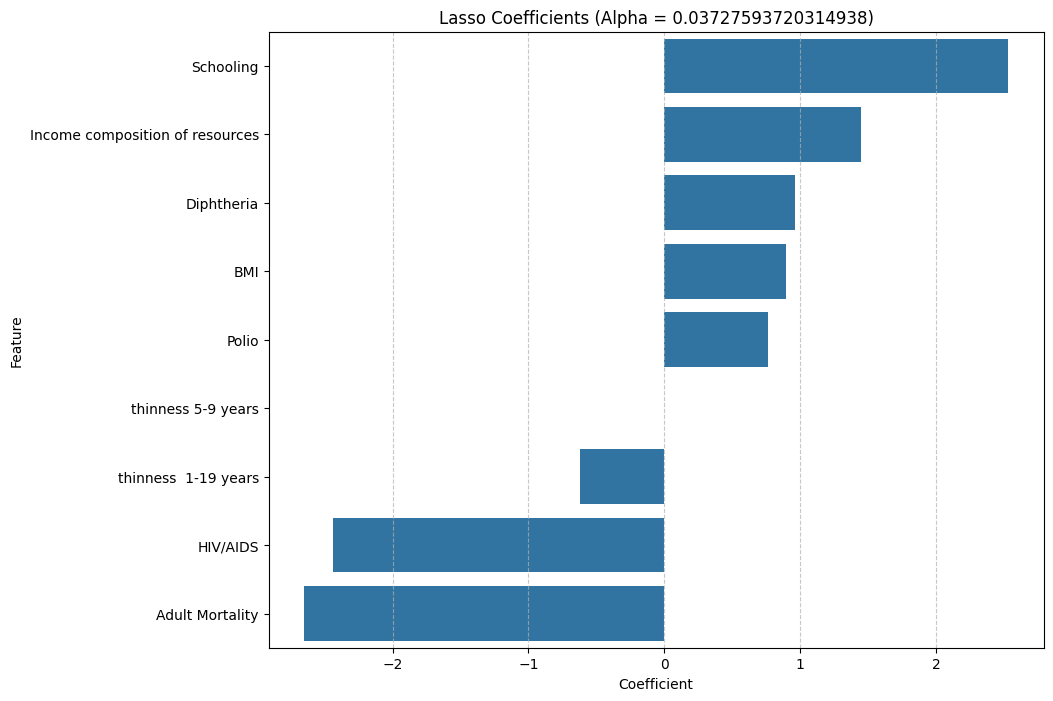

In [ ]:
# Creating a bar plot to visualize feature coefficients
plt.figure(figsize=(10,8))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_coefficients.sort_values(by='Coefficient', ascending=False)
)
plt.title(f"Lasso Coefficients (Alpha = {best_alpha})")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#rmse , r2 score
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
feature_coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lasso_model.coef_
})

print("Best Alpha (Regularization Strength):", best_alpha)
print("\nTrain RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("\nTrain R² Score:", train_r2)
print("Test R² Score:", test_r2)
print("\nTrain Score using model.score():", lasso_model.score(X_train_scaled, y_train))
print("Test Score using model.score():", lasso_model.score(X_test_scaled, y_test))

Best Alpha (Regularization Strength): 0.03727593720314938

Train RMSE: 4.278879293192885
Test RMSE: 4.137310291502665

Train R² Score: 0.8003153016604206
Test R² Score: 0.8021103500308792

Train Score using model.score(): 0.8003153016604206
Test Score using model.score(): 0.8021103500308792


In [ ]:
# Create a Series of coefficients with feature names as index
coefficients = pd.Series(lasso_model.coef_, index=X.columns)
# Features with zero coefficients
selected = coefficients[coefficients != 0]
excluded = coefficients[coefficients == 0]

print("Total Features:", len(coefficients))
print("Selected Features by Lasso:", len(selected))
print("Excluded Features by Lasso:", len(excluded))
print("\nSelected Features:\n", selected)
print("\nExcluded Features:\n", excluded)

Total Features: 9
Selected Features by Lasso: 8
Excluded Features by Lasso: 1

Selected Features:
 Schooling                          2.532694
Income composition of resources    1.450816
BMI                                0.896640
Diphtheria                         0.961618
Polio                              0.762764
thinness  1-19 years              -0.621811
HIV/AIDS                          -2.442540
Adult Mortality                   -2.654672
dtype: float64

Excluded Features:
 thinness 5-9 years   -0.0
dtype: float64


In [ ]:
#coef for all features
ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_scaled, y_train)
lasso = Lasso(alpha=best_alpha)
lasso.fit(X_train_scaled, y_train)
ridge_coef = pd.Series(ridge.coef_, index=X.columns)
lasso_coef = pd.Series(lasso.coef_, index=X.columns)

print("Ridge Coefficients:\n", ridge_coef)
print("\nLasso Coefficients:\n", lasso_coef)

Ridge Coefficients:
 Schooling                          2.534277
Income composition of resources    1.457533
BMI                                0.905414
Diphtheria                         0.974438
Polio                              0.777471
thinness 5-9 years                 0.007130
thinness  1-19 years              -0.644836
HIV/AIDS                          -2.464897
Adult Mortality                   -2.661415
dtype: float64

Lasso Coefficients:
 Schooling                          2.532694
Income composition of resources    1.450816
BMI                                0.896640
Diphtheria                         0.961618
Polio                              0.762764
thinness 5-9 years                -0.000000
thinness  1-19 years              -0.621811
HIV/AIDS                          -2.442540
Adult Mortality                   -2.654672
dtype: float64


In [ ]:
# Count features with non-zero Ridge and lasso coefficients
print("Ridge kept features:", sum(ridge_coef != 0))
print("Lasso kept features:", sum(lasso_coef != 0))

Ridge kept features: 9
Lasso kept features: 8


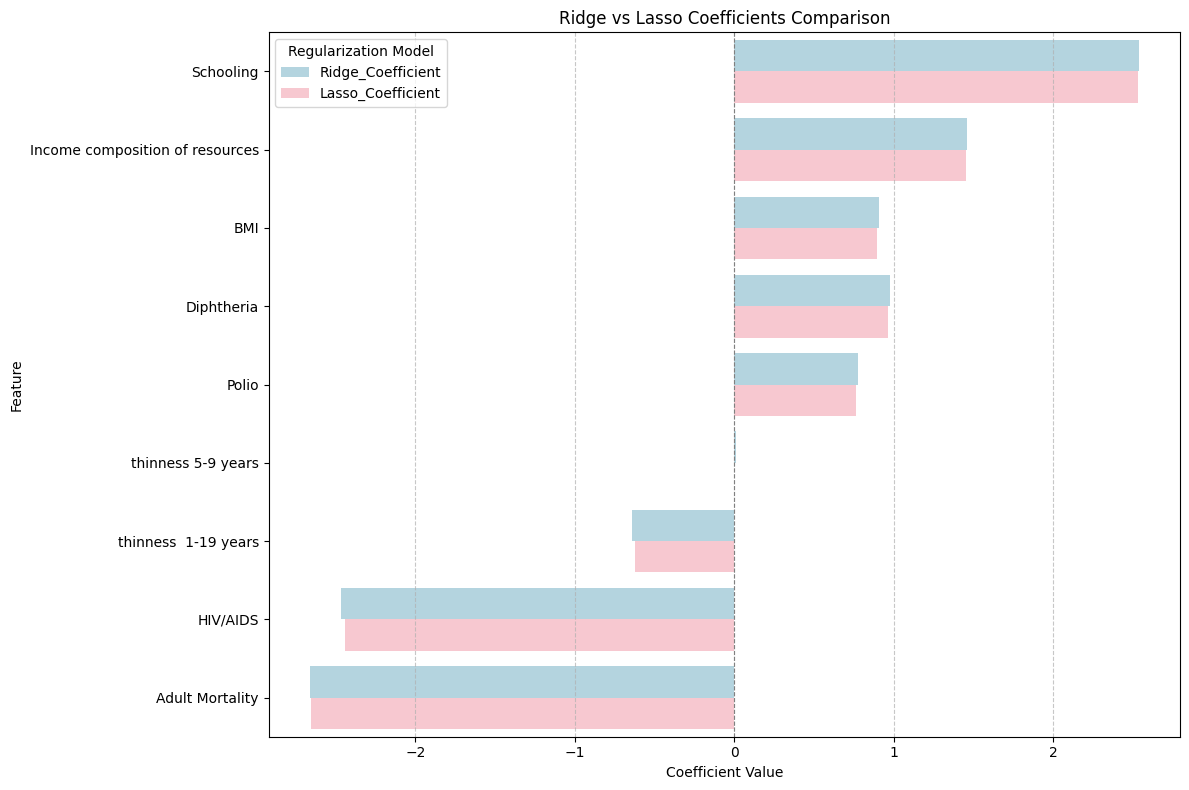

In [ ]:
#plotting both ridge and lasso regression
coefficients_df = pd.DataFrame({
    'Feature': ridge_coef.index,
    'Ridge_Coefficient': ridge_coef.values,
    'Lasso_Coefficient': lasso_coef.values
})

melted_coefficients = coefficients_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=melted_coefficients,
            palette={'Ridge_Coefficient': '#ADD8E6', 'Lasso_Coefficient': '#FFC0CB'})
plt.title("Ridge vs Lasso Coefficients Comparison")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Regularization Model')
plt.tight_layout()
plt.show()